# Ejercicio N°3

La siguiente tabla representa cinco canciones con sus vectores de frecuencia de términos, construidos a partir de las letras de cada una (vocabulario simplificado de 6 palabras):

|           | ”amor” | “noche” | “sol” | “lluvia” | “tiempo” | “vida” |
| ---       | ---    | ---     | ---   | ---      | ---      | ---    |
| cancion_1 | 8      | 1       | 0     | 0        | 2        | 5      |
| cancion_2 | 6      | 0       | 0     | 1        | 3        | 4      | 
| cancion_3 | 0      | 7       | 3     | 5        | 1        | 0      |
| cancion_4 | 1      | 6       | 2     | 4        | 0        | 0      |
| cancion_5 | 5      | 0       | 8     | 0        | 1        | 3      |

1. ¿Qué medida propondría para evaluar la similaridad de las canciones, basada en el conjunto de términos que componen el vocabulario simplificado?

2. Calcule manualmente dicha medida considerando `cancion_1` y `cancion_2` y verifique el resultado utilizando herramientas de la librería `SciPy`.

3. Calcule la matriz completa de similaridades entre las cinco canciones y represéntela visualmente mediante un gráfico apropiado. ¿Qué pares de canciones resultan más similares entre sí?

---

In [ ]:
# Librerías

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform, cosine
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Generamos un DataFrame con las 5 canciones

df = pd.DataFrame({
    'amor': [8, 6, 0, 1, 5],
    'noche': [1, 0, 7, 6, 0],
    'sol': [0, 0, 3, 2, 8],
    'lluvia': [0, 1, 5, 4, 0],
    'tiempo': [2, 3, 1, 0, 1],
    'vida': [5, 4, 0, 0, 3]
                            }, 
    index = ['c1', 'c2', 'c3', 'c4', 'c5'])

df

,amor,noche,sol,lluvia,tiempo,vida
c1,8,1,0,0,2,5
c2,6,0,0,1,3,4
c3,0,7,3,5,1,0
c4,1,6,2,4,0,0
c5,5,0,8,0,1,3


In [28]:
# Para este tipo de datos (frecuencia de palabras en canciones), una de las medidas 
# más apropiadas es la similitud del coseno.

# En el caso de las dos primeras funciones, calculamos su similutd coseno
# directa:

x = df.loc['c1']
y = df.loc['c2']
sim_manual = 1 - cosine(x, y)

print("Similitud coseno:", round(sim_manual, 4))

Similitud coseno: 0.9693


In [ ]:
# Matriz de distancias coseno entre todas las canciones:

dist_cos = pd.DataFrame(
    1 - squareform(pdist(df.values, metric='cosine')),
    index = df.index,
    columns = df.index
)

print("Matriz de distancias coseno:\n")
print(dist_cos.round(3))

Matriz de distancias coseno:

       c1     c2     c3     c4     c5
c1  1.000  0.969  0.101  0.191  0.591
c2  0.969  1.000  0.111  0.168  0.574
c3  0.101  0.111  1.000  0.983  0.274
c4  0.191  0.168  0.983  1.000  0.280
c5  0.591  0.574  0.274  0.280  1.000


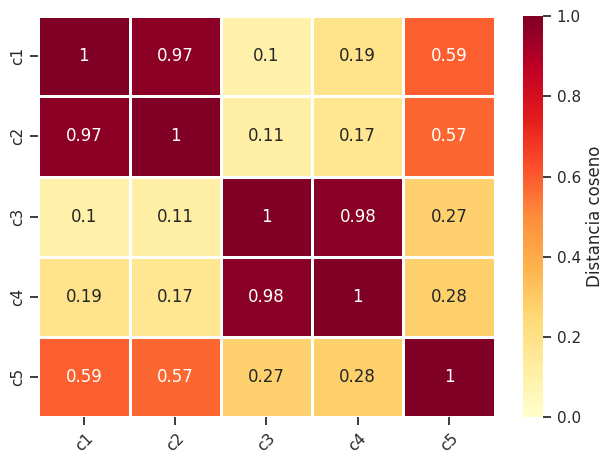

In [39]:
sns.set_theme(style = 'ticks')

ax = sns.heatmap(dist_cos, annot = True, cmap = 'YlOrRd', vmin = 0, vmax = 1,
                    linewidths = 0.9, annot_kws = {"fontsize": 12},
                    cbar_kws = dict(label = 'Distancia coseno'))
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()